<h1>Train — DenseNet-121</h1>

Trains and evaluates DenseNet-121 using the tuned hyperparameters from `ARCH_HYPERPARAMS["densenet121"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): NoordelikeWerke
Train-time augmentation: on
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1707 | Val: 415 | Test: 405


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["densenet121"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"DenseNet-121: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

DenseNet-121: micro batch = 16, accumulation steps = 3 (effective batch size ≈ 48, tuned value = 48)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with DenseNet-121)
# ---------------------------------------------------------
model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
in_f = model.classifier.in_features
model.classifier = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the Bayesian-optimized step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[DenseNet-121] Using gradient accumulation: 3 micro-batches per optimizer step (effective batch size ≈ micro_batch x 3).


[DenseNet-121] Epoch   1/100 | LR: 3.44e-04 | train loss 0.9094 acc 0.605 | val loss 0.7236 acc 0.716 *


[DenseNet-121] Epoch   2/100 | LR: 3.44e-04 | train loss 0.7214 acc 0.698 | val loss 0.5812 acc 0.771 *


[DenseNet-121] Epoch   3/100 | LR: 3.44e-04 | train loss 0.5661 acc 0.732 | val loss 0.5479 acc 0.788 *


[DenseNet-121] Epoch   4/100 | LR: 3.44e-04 | train loss 0.5337 acc 0.771 | val loss 0.5423 acc 0.786 *


...

[DenseNet-121] Epoch  11/100 | LR: 3.44e-05 | train loss 0.2711 acc 0.865 | val loss 0.5506 acc 0.817


[DenseNet-121] Epoch  12/100 | LR: 3.44e-05 | train loss 0.2103 acc 0.893 | val loss 0.4259 acc 0.863


[DenseNet-121] Epoch  13/100 | LR: 3.44e-05 | train loss 0.1574 acc 0.924 | val loss 0.4104 acc 0.865


[DenseNet-121] Epoch  14/100 | LR: 3.44e-05 | train loss 0.1759 acc 0.919 | val loss 0.3880 acc 0.877


[DenseNet-121] Epoch  15/100 | LR: 3.44e-05 | train loss 0.1449 acc 0.934 | val loss 0.4051 acc 0.872

[DenseNet-121] No val loss improvement for 10 epochs — stopping early at epoch 15.

[DenseNet-121] Restored best checkpoint (val loss = 0.3572)


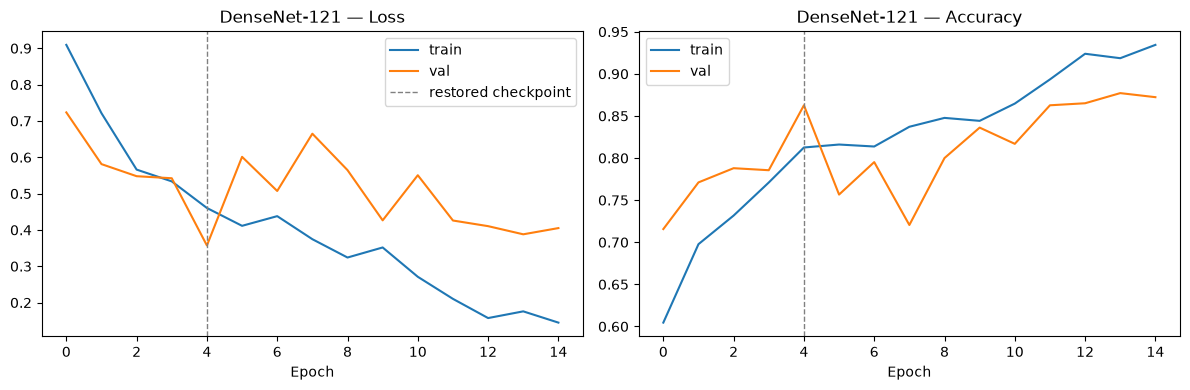

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "DenseNet-121", is_inception=False,
    accum_steps=accum_steps,
)
plot_training_curves(history, "DenseNet-121")

## Evaluate on the test set

[DenseNet-121] Test accuracy: 0.847


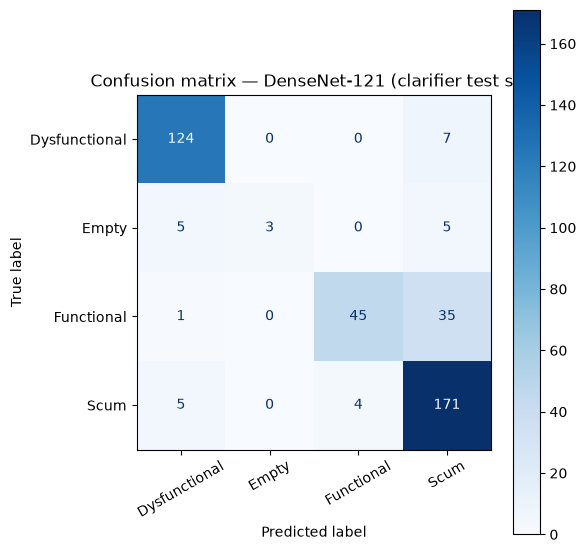

               precision    recall  f1-score   support

Dysfunctional      0.919     0.947     0.932       131
        Empty      1.000     0.231     0.375        13
   Functional      0.918     0.556     0.692        81
         Scum      0.784     0.950     0.859       180

     accuracy                          0.847       405
    macro avg      0.905     0.671     0.715       405
 weighted avg      0.861     0.847     0.834       405



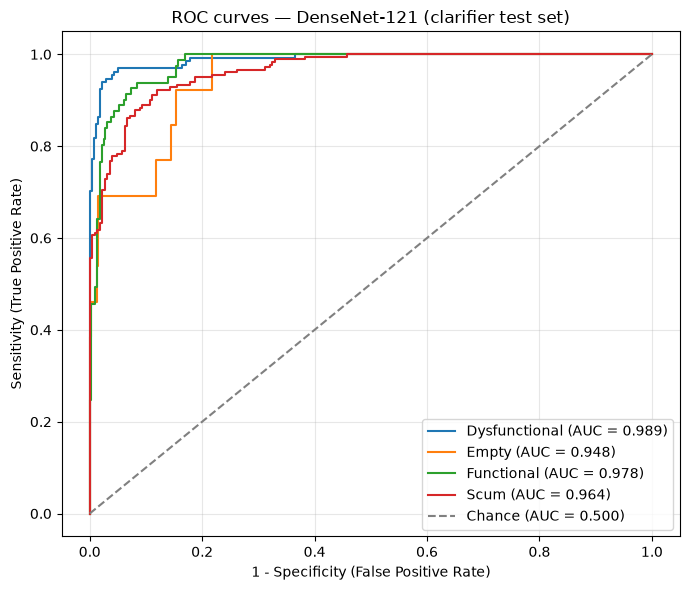

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.989
  Empty          : 0.948
  Functional     : 0.978
  Scum           : 0.964

Mean AUC (over 4/4 classes with test examples): 0.970


(np.float64(0.8469135802469135),
 {'Dysfunctional': 0.9894411322226555,
  'Empty': 0.9478021978021978,
  'Functional': 0.9780140222527054,
  'Scum': 0.9636543209876542})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "DenseNet-121", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("DenseNet-121", "densenet121")

Saved results to ../results/clarifier_aug/results_clarifier_densenet121_NoordelikeWerke.pkl
Saved model weights to ../models/clarifier_densenet121_cnn.pt
